# Figure Factory

In [11]:
# set up paths to local module
import sys 
from pathlib import Path
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

from decanopy.models.RSC import heat_mapping_helper as hm

import pickle 
import importlib
importlib.reload(hm)

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Garamond', 'EB Garamond'] + plt.rcParams['font.serif']

In [12]:
readpath = '../data/output/rsc/rand_sky/heatmap'
savepath = "./aea26/"

### Data

In [5]:
# N&P data 
# calculated from NP sheet in NP_data.xlsx
uscNP = 48 # 47+1 because of the "?"", maybe?
histNP = {-3: 14, -2: 15, -1: 49, 0: 138, 1: 45, 2: 25, 3: 26} # total of 312 stars
R0NP, R1NP, RsNP = hm.compute_ratios(histNP)


# synRSC data 
# random_sky_dict = sa.scan_folder(readpath)
with open("rand_sky_RSCs_dict", "rb") as f:
    rand_sky_RSCs_dict = pickle.load(f)

with open("real_sky_RSCs_dict", "rb") as f:
    real_sky_RSCs_dict = pickle.load(f)

# Figures

## Heatmaps

### individual

In [6]:
title_dict = {
    "unicount": "Unique star counts for", 
    "R0": "$R_0$ for ",
    "R1": "$R_1$ for ",
    "S": "$R_s$ for "
    }

clabel_dict = {
    "unicount": "unique star count minus N&P value", 
    "R0": "$R_0 - R_0^{N&P}$",
    "R1": "$R_1 - R_1^{N&P}$",
    "S": "$R_s - R_s^{N&P}$"
    }

ref_vals_dict = {
    "unicount": uscNP, 
    "R0": R0NP,
    "R1": R1NP,
    "S": RsNP
}

clims_dict = {
    "unicount": (-20, 0, 20), 
    "R0": (-R0NP, R0NP),
    "R1": (-R1NP, R1NP),
    "S":  (-RsNP, RsNP)
}

def save_plots(sky_dict, name, metric, savepath):
    # metric-specific things
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    title = title_dict[metric] + name + " Select"
    clabel = clabel_dict[metric]
    savepath = savepath + metric + "/"
    
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value

    # dark figure
    fig, ax  = hm.plot_heatmap(grid, title, cmap = "twilight", clims = clims, clabel = clabel)
    fig.savefig(savepath + metric + "_" + name + "_dark.png")
    plt.close(fig)

    # light figure
    fig, ax  = hm.plot_heatmap(grid, title, cmap = "BrBG", clims = clims, clabel = clabel)
    fig.savefig(savepath + metric + "_" + name + "_light.png")
    plt.close(fig) 


In [7]:
# iterate through selectiomn algorithms and metric choices
select_algs = ['Mag', 'Name', 'DBC', 'CBin', 'Full']
metric_keys = ['unicount', 'R0', 'R1', 'S']

# # save all random sky figures
# for name in select_algs: 
#     for metric in metric_keys:
#         save_plots(rand_sky_RSCs_dict, name, metric, "./aea26/rand_sky/")

# # save all real sky figures
# for name in select_algs: 
#     for metric in metric_keys:
#         save_plots(real_sky_RSCs_dict, name, metric, "./aea26/real_sky/")

### 3x1 grids

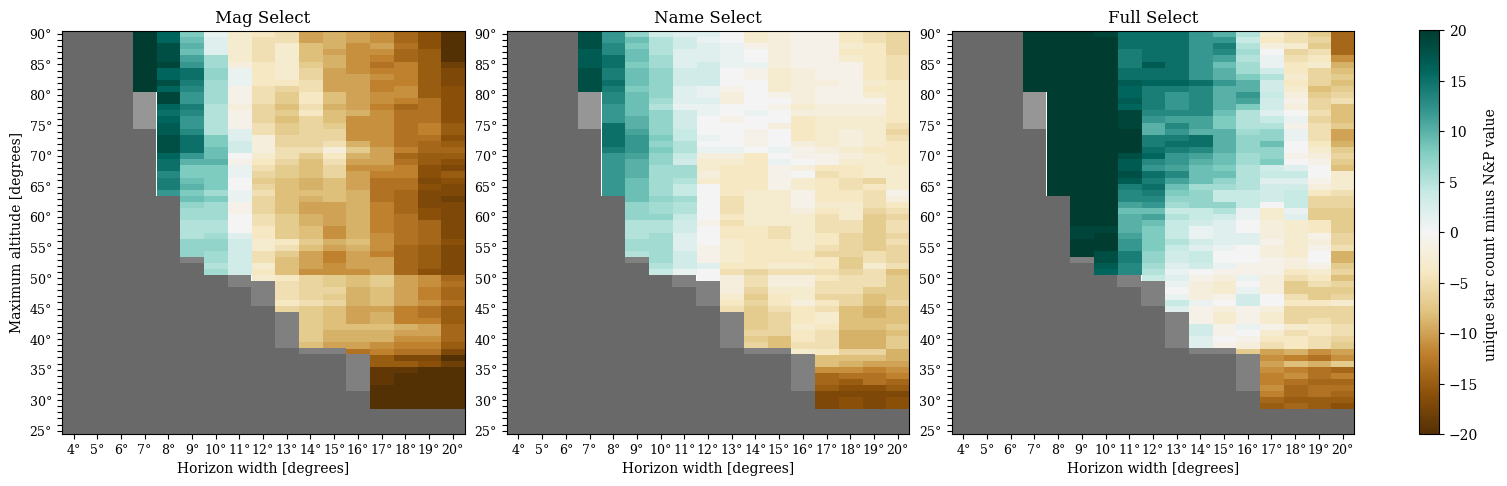

In [ ]:
sky_dict = real_sky_RSCs_dict
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'unicount'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value
    gridlist.append(grid)


importlib.reload(hm)

fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

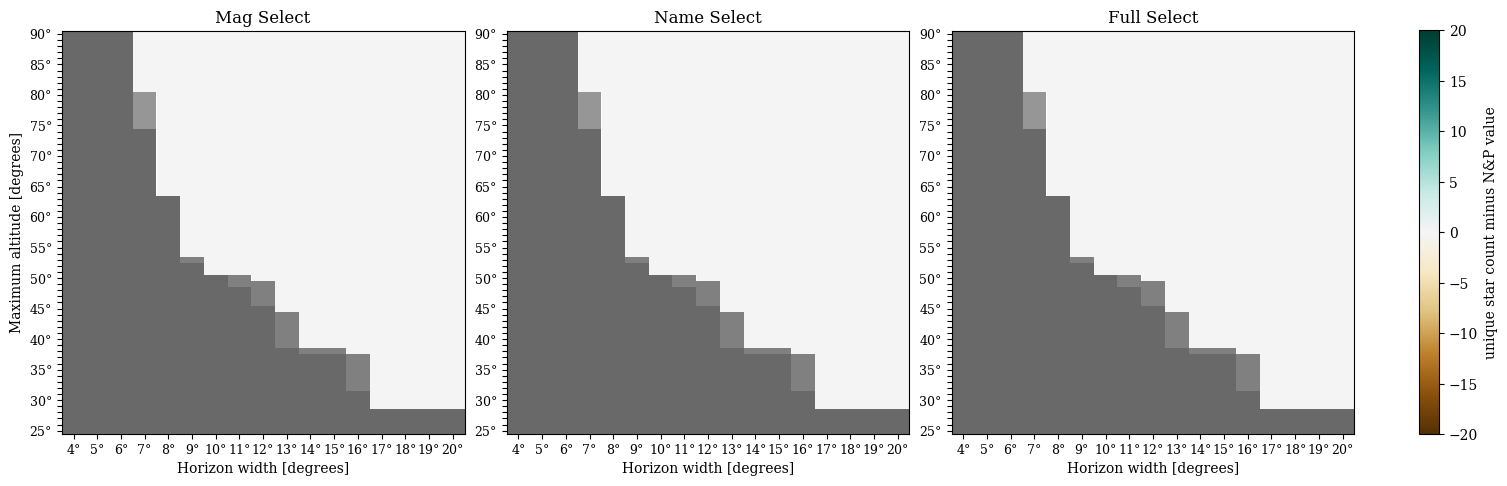

In [457]:
sky_dict = real_sky_RSCs_dict
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'unicount'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] = 0 # testing
    gridlist.append(grid)


importlib.reload(hm)

fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

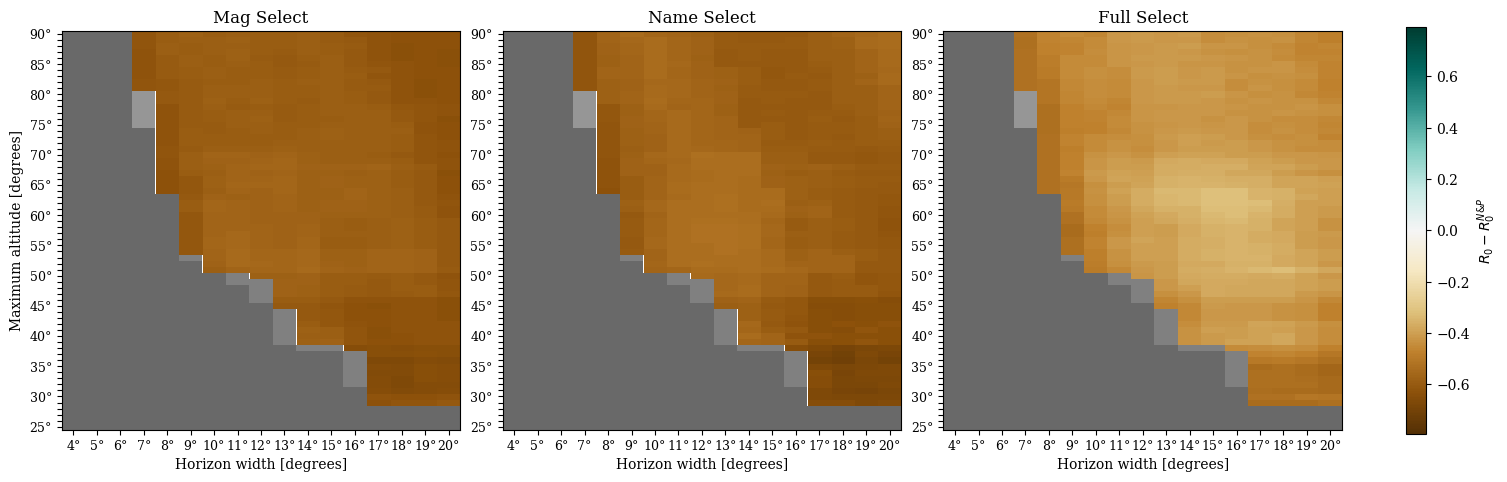

In [429]:
sky_dict = real_sky_RSCs_dict
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'R0'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value
    gridlist.append(grid)



importlib.reload(hm)

fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

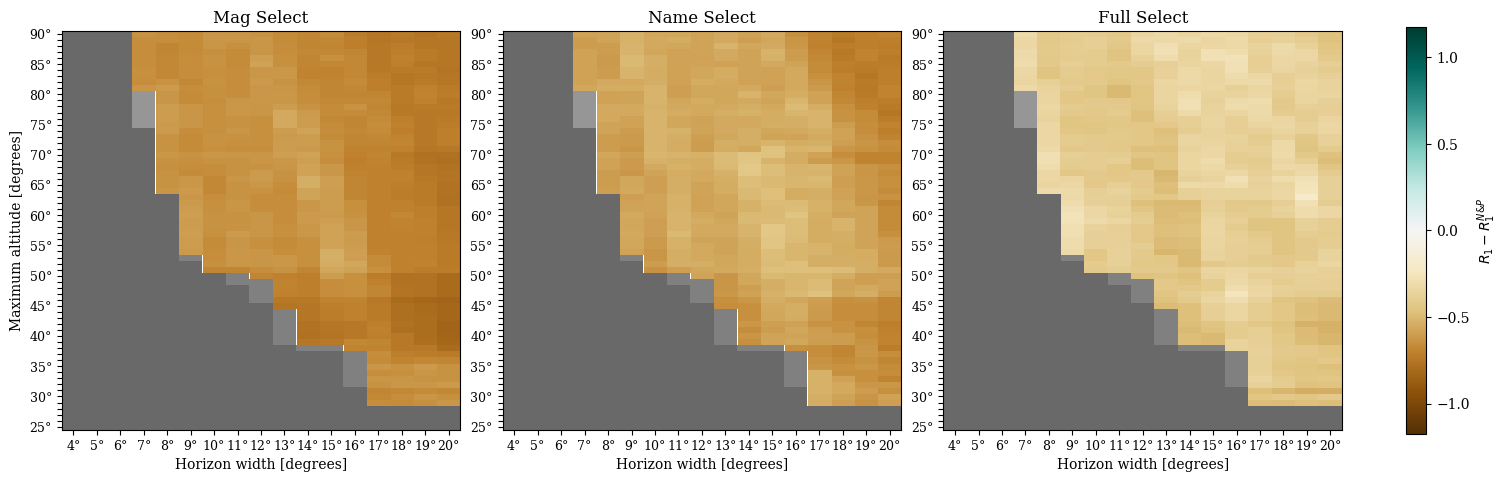

In [430]:
sky_dict = real_sky_RSCs_dict
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'R1'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value
    gridlist.append(grid)



importlib.reload(hm)

fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

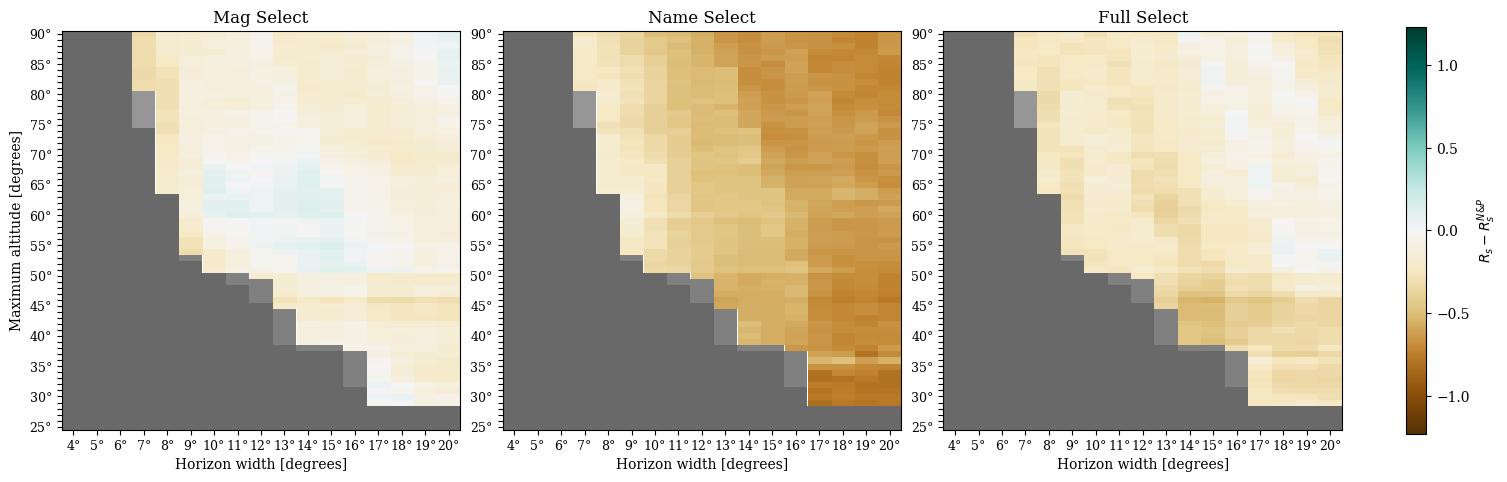

In [431]:
sky_dict = real_sky_RSCs_dict
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'S'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value
    gridlist.append(grid)



importlib.reload(hm)

fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

### Similarity Score [not working yet]

#### testing

In [ ]:
title_dict = {
    "unicount": "Unique star counts for ", 
    "R0": "$R_0$ for ",
    "R1": "$R_1$ for ",
    "S": "$R_s$ for "
    }

clabel_dict = {
    "unicount": "unique star count minus N&P value", 
    "R0": "$R_0 - R_0^{N&P}$",
    "R1": "$R_1 - R_1^{N&P}$",
    "S": "$R_s - R_s^{N&P}$"
    }

ref_vals_dict = {
    "unicount": uscNP, 
    "R0": R0NP,
    "R1": R1NP,
    "S": RsNP
}

clims_dict = {
    "unicount": (-20, 0, 20), 
    "R0": (-R0NP, R0NP),
    "R1": (-R1NP, R1NP),
    "S":  (-RsNP, RsNP)
}

def similatiy_figures(sky_dict, name, metric, savepath):
    # metric-specific things
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    title = title_dict[metric] + name + " Select"
    clabel = clabel_dict[metric]
    savepath = savepath #+ metric + "/"
    
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value

    # dark figure
    fig, ax  = hm.plot_heatmap(grid, title, cmap = "twilight", clims = clims, clabel = clabel)
    fig.savefig(savepath + metric + "_" + name + "_dark.png")
    plt.close(fig)

    # light figure
    fig, ax  = hm.plot_heatmap(grid, title, cmap = "BrBG", clims = clims, clabel = clabel)
    fig.savefig(savepath + metric + "_" + name + "_light.png")
    plt.close(fig) 


In [142]:
# import heat_mapping_helper as hm

# # iterate through selection algorithms and metric choices
# select_algs = ['Mag', 'Name', 'DBC', 'CBin', 'Full']
# metric_keys = ['unicount', 'R0', 'R1', 'S']

# # save all real sky figures
# gridlist = []
# for name in select_algs: 
#     templist = []
#     for metric in metric_keys:
#         grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric=metric)
#         ref_val = ref_vals_dict[metric]
#         grid[grid >= 0] -= ref_val # subtract reference value
#         templist.append(grid)
#     gridlist.append(templist)

In [ ]:
name = select_algs[-1]
metric = metric_keys[0]
ref_val = ref_vals_dict[metric]
title = title_dict[metric] + name + " Select"
print(metric, ":", ref_val)

grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric=metric)
print(metric, ":", ref_val)
print(grid[20][65])

unicount : 48
45


In [165]:
name = select_algs[-1]
metric = metric_keys[0]
ref_val = ref_vals_dict[metric]
title = title_dict[metric] + name + " Select"
print(metric, ":", ref_val)

grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric="hist")

unicount : 48


In [167]:
# iterate through selectiomn algorithms and metric choices
select_algs = ['Mag', 'Name', 'DBC', 'CBin', 'Full']
metric_keys = ['unicount', 'R0', 'R1', 'S']

# save all random sky figures
for name in select_algs: 
    for metric in metric_keys:
        grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric=metric)
        print(name, metric, ":", np.round(grid[20][65], 3))
        print(grid)

Mag unicount : 31
horizon_width    4     5     6     7     8     9     10    11    12    13  \
alt_hi_label                                                                
25            -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003   
26            -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003   
27            -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003   
28            -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003   
29            -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003 -1003   
...             ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   
86            -1003 -1003 -1003    73    66    59    54    45    43    45   
87            -1003 -1003 -1003    73    66    57    50    45    43    45   
88            -1003 -1003 -1003    71    66    58    50    45    43    45   
89            -1003 -1003 -1003    71    64    57    50    45    43    43   
90            -1003 -1003 -1003    71    64    56    49   

In [172]:
# iterate through selectiomn algorithms and metric choices
select_algs = ['Mag', 'Name', 'Full']
for name in select_algs:
    hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
    print(hist[20][65])

{-3: 51, -2: 42, -1: 35, 0: 44, 1: 43, 2: 51, 3: 46}
{-3: 57, -2: 59, -1: 54, 0: 50, 1: 36, 2: 28, 3: 28}
{-3: 28, -2: 28, -1: 47, 0: 89, 1: 52, 2: 37, 3: 31}


#### grids

In [432]:
title_dict = {
    "unicount": "Unique star counts for", 
    "R0": "$R_0$ for ",
    "R1": "$R_1$ for ",
    "S": "$R_s$ for "
    }

clabel_dict = {
    "unicount": "unique star count minus N&P value", 
    "R0": "$R_0 - R_0^{N&P}$",
    "R1": "$R_1 - R_1^{N&P}$",
    "S": "$R_s - R_s^{N&P}$"
    }

ref_vals_dict = {
    "unicount": uscNP, 
    "R0": R0NP,
    "R1": R1NP,
    "S": RsNP
}

clims_dict = {
    "unicount": (-20, 0, 20), 
    "R0": (-R0NP, R0NP),
    "R1": (-R1NP, R1NP),
    "S":  (-RsNP, RsNP)
}

def save_plots(sky_dict, name, metric, savepath):
    # metric-specific things
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    title = title_dict[metric] + name + " Select"
    clabel = clabel_dict[metric]
    savepath = savepath + metric + "/"
    
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value

    # dark figure
    fig, ax  = hm.plot_heatmap(grid, title, cmap = "twilight", clims = clims, clabel = clabel)
    fig.savefig(savepath + metric + "_" + name + "_dark.png")
    plt.close(fig)

    # light figure
    fig, ax  = hm.plot_heatmap(grid, title, cmap = "BrBG", clims = clims, clabel = clabel)
    fig.savefig(savepath + metric + "_" + name + "_light.png")
    plt.close(fig) 


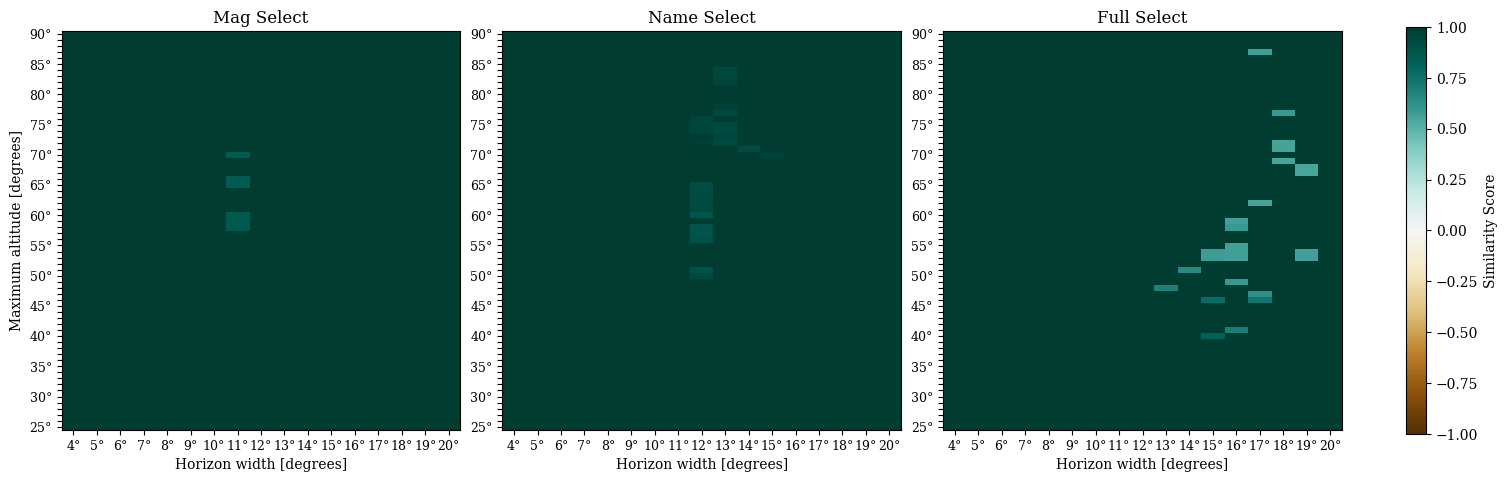

In [435]:
sky_dict = real_sky_RSCs_dict

# iterate through selectiomn algorithms
gridlist = []
titles = []

for name in select_algs:
    #cycle through metrics to make grids
    titles.append(name + " Select")
    # add up grids of merics
    metric_gridlist = 0
    for metric in metric_keys:
        #calculate & normalize grid
        ref_val = ref_vals_dict[metric]
        grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
        grid[grid >= 0] -= ref_val # subtract reference value
        grid[grid >= 0] / ref_val
        metric_gridlist += grid**2
    gridlist.append(np.sqrt(metric_gridlist))

# plotting niceties 
clabel = "Similarity Score"
clims = (-1, 1)

importlib.reload(hm)

fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

In [ ]:
import numpy as np
import matplotlib.colors as mcolors

name = select_algs[-1]
metric = metric_keys[0]
ref_val = ref_vals_dict[metric]
title = title_dict[metric] + name + " Select"
print(metric, ":", ref_val)

grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric=metric)
grid[grid <= 0] -= np.nan
grid[grid >= 0] -= ref_val # subtract reference value
grid[grid >= 0] /= ref_val # divide reference value

plot_data = np.abs(grid.copy().astype(float))
mindev = plot_data.min().min()
print("mindev", ":", mindev)
#plt.imshow(plot_data, aspect='equal')

fig, ax = plt.subplots(figsize=(7,7))
norm = mcolors.Normalize(vmin=0, vmax=1)
im = ax.imshow(plot_data, aspect = 'auto', norm=norm)
fig.colorbar(im, ax=ax)
fig.tight_layout()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
sky_dict = real_sky_RSCs_dict
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'unicount'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value
    gridlist.append(grid)


importlib.reload(hm)

fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

## Histograms

### initial tests

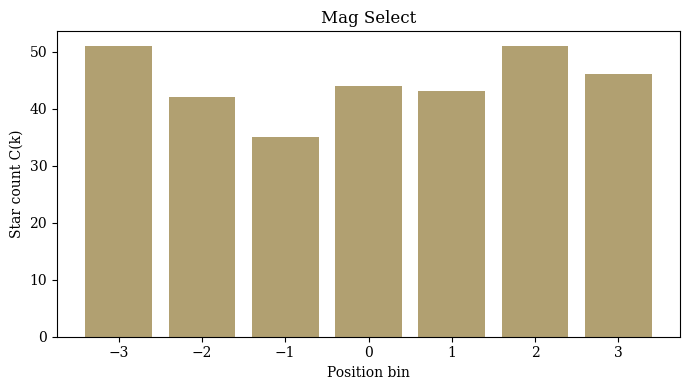

In [199]:
name = 'Mag'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
keys = [-3, -2, -1, 0, 1, 2, 3]
vals = [hist[20][65][k] for k in keys]

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(keys, vals, color="#B1A071")
ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_title(name + " Select")
fig.tight_layout()

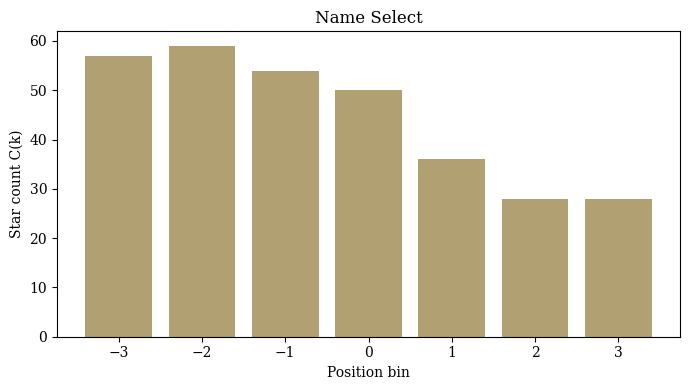

In [197]:
name = 'Name'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
keys = [-3, -2, -1, 0, 1, 2, 3]
vals = [hist[20][65][k] for k in keys]

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(keys, vals, color="#B1A071")
ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_title(name + " Select")
fig.tight_layout()

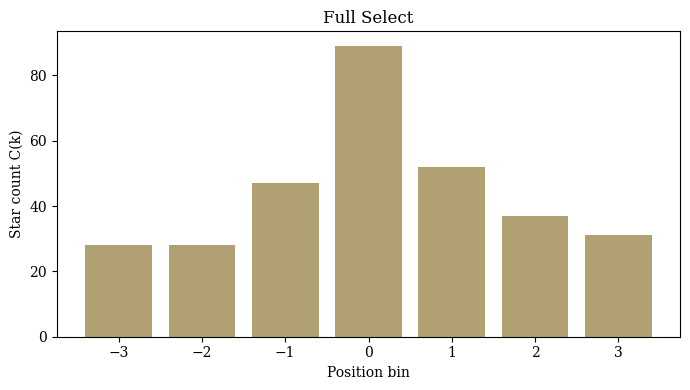

In [204]:
name = 'Full'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
keys = [-3, -2, -1, 0, 1, 2, 3]
vals = [hist[20][65][k] for k in keys]

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(keys, vals, color="#B1A071")
ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_title(name + " Select")
fig.tight_layout()

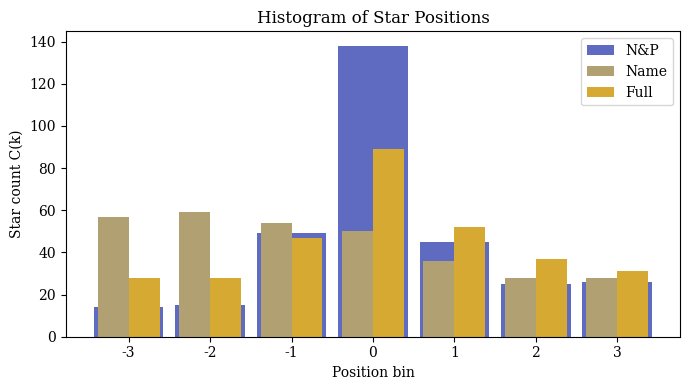

In [273]:
keys = [-3, -2, -1, 0, 1, 2, 3]
# N&P
name = 'N&P data'
valsNP = [histNP[k] for k in keys]

name = 'Name'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
valsName = [hist[20][65][k] for k in keys]

name = 'Full'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
valsFull = [hist[20][65][k] for k in keys]

# - - - - - - - - - - - 
# colors = ["#5F6BC1", "#B1A071", "#D5A932"]
# labels = ["N&P", "Name", "Full"]

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
#ax.bar(x, valsNP, width, label='N&P', color="#5F6BC1")
#ax.bar(x, valsNP, 2.5*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)
ax.bar(x, valsNP,  2.25*width, label='N&P', color="#5F6BC1")
ax.bar(x - 0.50 * width, valsName,  width, label='Name', color="#B1A071")
ax.bar(x + 0.50 * width, valsFull,  width, label='Full', color="#D5A932")

ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels
ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_title("Histogram of Star Positions")
ax.legend()

fig.tight_layout()

### For AEA Meeting ppt

In [325]:
keys = [-3, -2, -1, 0, 1, 2, 3]
# N&P
name = 'N&P data'
valsNP = [histNP[k] for k in keys]

name = 'Name'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
valsName = [hist[20][65][k] for k in keys]

name = 'Full'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
valsFull = [hist[20][65][k] for k in keys]


In [326]:
valsNP

[14, 15, 49, 138, 45, 25, 26]

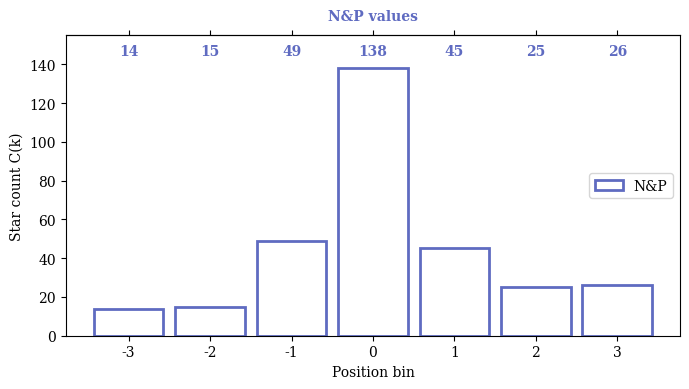

In [345]:
# N&P data
# - - - - - - - - - - - 

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
bar1 = ax.bar(x, valsNP, 2.25*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)

# bottom axis
ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels

# top axis for N&P numbers
secax = ax.secondary_xaxis('top')
secax.set_xticklabels([])  # Clears existing labels
secax.set_xlabel("N&P values", color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels([0]+valsNP, color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels(valsNP)  # Clears existing labels


for i in range(0, len(x)): 
    ax.text(x[i], 145, str(valsNP[i]), ha='center', color = "#5F6BC1", weight = 'bold')

ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_ylim(0, 155)
#ax.set_title("Histogram of Star Positions")
ax.legend(loc = 'center right')



fig.tight_layout()

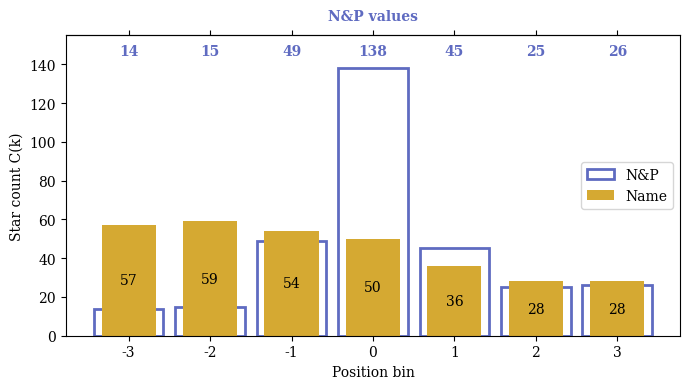

In [ ]:
# Name data
# - - - - - - - - - - - 

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
bar1 = ax.bar(x, valsNP, 2.25*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)
#ax.bar_label(bar1, padding=10, color = "#5F6BC1", weight = 'bold')
bar2 = ax.bar(x, valsName, 1.75* width, label='Name', color="#D5A932")
ax.bar_label(bar2, padding=0, label_type='center')

# bottom axis
ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels

# top axis for N&P numbers
secax = ax.secondary_xaxis('top')
secax.set_xticklabels([])  # Clears existing labels
secax.set_xlabel("N&P values", color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels([0]+valsNP, color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels(valsNP)  # Clears existing labels


for i in range(0, len(x)): 
    ax.text(x[i], 145, str(valsNP[i]), ha='center', color = "#5F6BC1", weight = 'bold')

ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_ylim(0, 155)
#ax.set_title("Histogram of Star Positions")
#ax.legend(loc = 'center right')



fig.tight_layout()

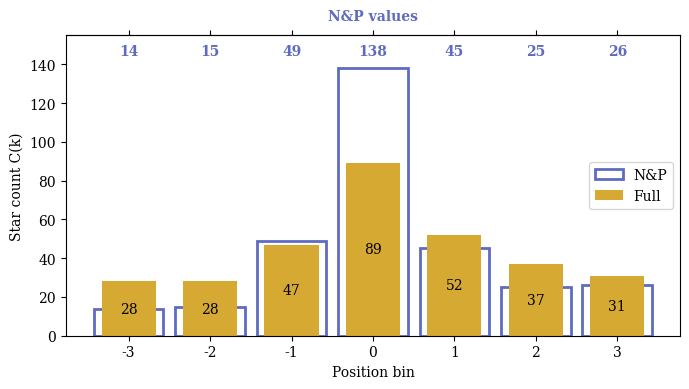

In [347]:
# Full data
# - - - - - - - - - - - 

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
bar1 = ax.bar(x, valsNP, 2.25*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)
#ax.bar_label(bar1, padding=10, color = "#5F6BC1", weight = 'bold')
bar2 = ax.bar(x, valsFull, 1.75* width, label='Full', color="#D5A932")
ax.bar_label(bar2, padding=0, label_type='center')

# bottom axis
ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels

# top axis for N&P numbers
secax = ax.secondary_xaxis('top')
secax.set_xticklabels([])  # Clears existing labels
secax.set_xlabel("N&P values", color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels([0]+valsNP, color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels(valsNP)  # Clears existing labels


for i in range(0, len(x)): 
    ax.text(x[i], 145, str(valsNP[i]), ha='center', color = "#5F6BC1", weight = 'bold')

ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_ylim(0, 155)
#ax.set_title("Histogram of Star Positions")
ax.legend(loc = 'center right')



fig.tight_layout()

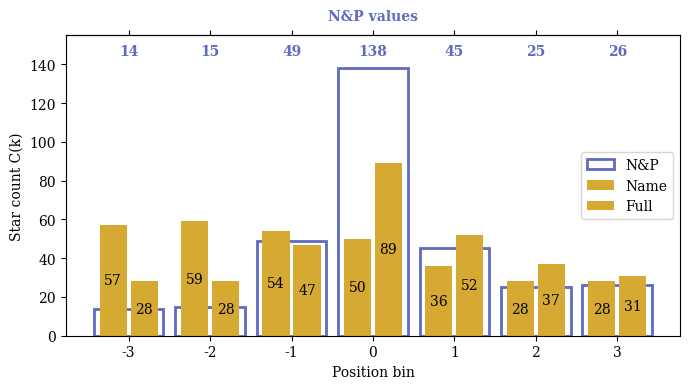

In [349]:
# Full data
# - - - - - - - - - - - 

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
bar1 = ax.bar(x, valsNP, 2.25*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)
#ax.bar_label(bar1, padding=10, color = "#5F6BC1", weight = 'bold')
bar2 = ax.bar(x-width/2, valsName, 1.75* width/2, label='Name', color="#D5A932")
ax.bar_label(bar2, padding=0, label_type='center')

bar3 = ax.bar(x+width/2, valsFull, 1.75* width/2, label='Full', color="#D5A932")
ax.bar_label(bar3, padding=0, label_type='center')

# bottom axis
ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels

# top axis for N&P numbers
secax = ax.secondary_xaxis('top')
secax.set_xticklabels([])  # Clears existing labels
secax.set_xlabel("N&P values", color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels([0]+valsNP, color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels(valsNP)  # Clears existing labels


for i in range(0, len(x)): 
    ax.text(x[i], 145, str(valsNP[i]), ha='center', color = "#5F6BC1", weight = 'bold')

ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_ylim(0, 155)
#ax.set_title("Histogram of Star Positions")
ax.legend(loc = 'center right')



fig.tight_layout()

### more tests

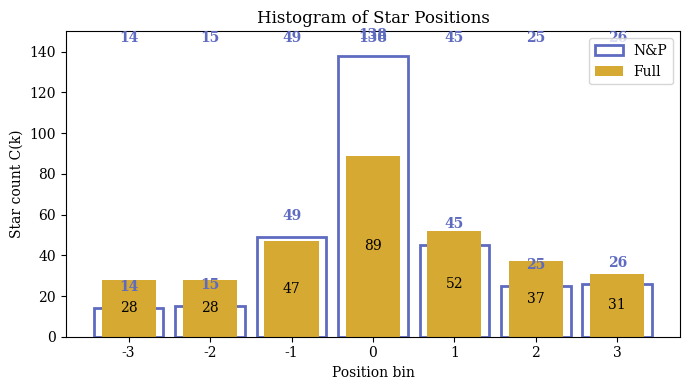

In [307]:
keys = [-3, -2, -1, 0, 1, 2, 3]
# N&P
name = 'N&P data'
valsNP = [histNP[k] for k in keys]

name = 'Name'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
valsName = [hist[20][65][k] for k in keys]

name = 'Full'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
valsFull = [hist[20][65][k] for k in keys]

# - - - - - - - - - - - 
# colors = ["#5F6BC1", "#B1A071", "#D5A932"]
# labels = ["N&P", "Name", "Full"]

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
#ax.bar(x, valsNP, width, label='N&P', color="#5F6BC1")
bar1 = ax.bar(x, valsNP, 2.25*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)
ax.bar_label(bar1, padding=10, color = "#5F6BC1", weight = 'bold')
bar2 = ax.bar(x, valsFull, 1.75* width, label='Full', color="#D5A932")
ax.bar_label(bar2, padding=0, label_type='center')

for i in range(0, len(x)): 
    ax.text(x[i], 145, str(valsNP[i]), ha='center', color = "#5F6BC1", weight = 'bold')

ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels
ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_ylim(0, 150)
ax.set_title("Histogram of Star Positions")
ax.legend()

fig.tight_layout()

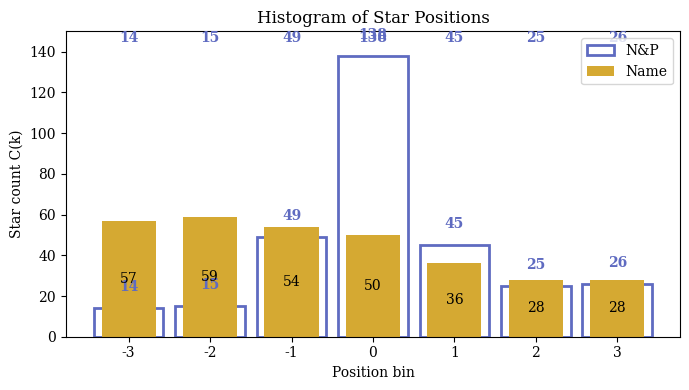

In [308]:
keys = [-3, -2, -1, 0, 1, 2, 3]
# N&P
name = 'N&P data'
valsNP = [histNP[k] for k in keys]

name = 'Name'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
valsName = [hist[20][65][k] for k in keys]

name = 'Full'
hist = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric='hist')
valsFull = [hist[20][65][k] for k in keys]

# - - - - - - - - - - - 
# colors = ["#5F6BC1", "#B1A071", "#D5A932"]
# labels = ["N&P", "Name", "Full"]

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
#ax.bar(x, valsNP, width, label='N&P', color="#5F6BC1")
bar1 = ax.bar(x, valsNP, 2.25*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)
ax.bar_label(bar1, padding=10, color = "#5F6BC1", weight = 'bold')
bar2 = ax.bar(x, valsName, 1.75* width, label='Name', color="#D5A932")
ax.bar_label(bar2, padding=0, label_type='center')


for i in range(0, len(x)): 
    ax.text(x[i], 145, str(valsNP[i]), ha='center', color = "#5F6BC1", weight = 'bold')


ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels
ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_ylim(0, 150)
ax.set_title("Histogram of Star Positions")
ax.legend()

fig.tight_layout()

In [220]:
data = np.transpose(np.array([valsNP, vals_full, vals]))
data.shape


(7, 3)

In [222]:
vals

[28, 28, 47, 89, 52, 37, 31]

## Scratch

### minimum devs

unicount : 48
mindev : 0.0


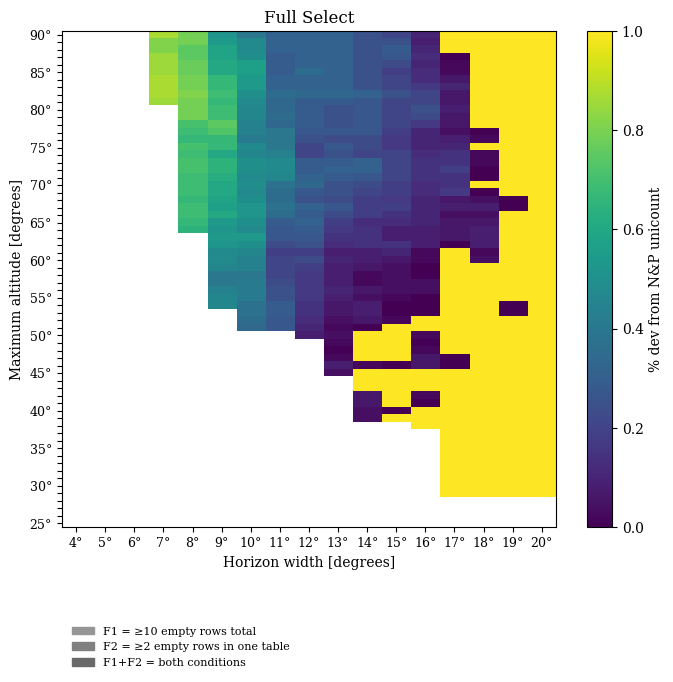

In [443]:
import numpy as np
import matplotlib.colors as mcolors

name = select_algs[-1]
metric = metric_keys[0]
ref_val = ref_vals_dict[metric]
title = title_dict[metric] + name + " Select"
print(metric, ":", ref_val)

grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric=metric)
grid[grid <= 0] -= np.nan
grid[grid >= 0] -= ref_val # subtract reference value
grid[grid >= 0] /= ref_val # divide reference value

plot_data = np.abs(grid.copy().astype(float))
mindev = plot_data.min().min()
print("mindev", ":", mindev)
#plt.imshow(plot_data, aspect='equal')

# fig, ax = plt.subplots(figsize=(7,7))
# norm = mcolors.Normalize(vmin=0, vmax=1)
# im = ax.imshow(plot_data, aspect = 'auto', norm=norm)
# fig.colorbar(im, ax=ax)
# fig.tight_layout()
# ax.invert_yaxis()
# plt.tight_layout()
# plt.show()


fig, ax  = hm.plot_heatmap(plot_data,  name + " Select", 
                           cmap = "viridis", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, 1),
                           clabel = "% dev from N&P " + metric
                           )


R0 : 0.7931034482758621
mindev : 0.3214053350683149


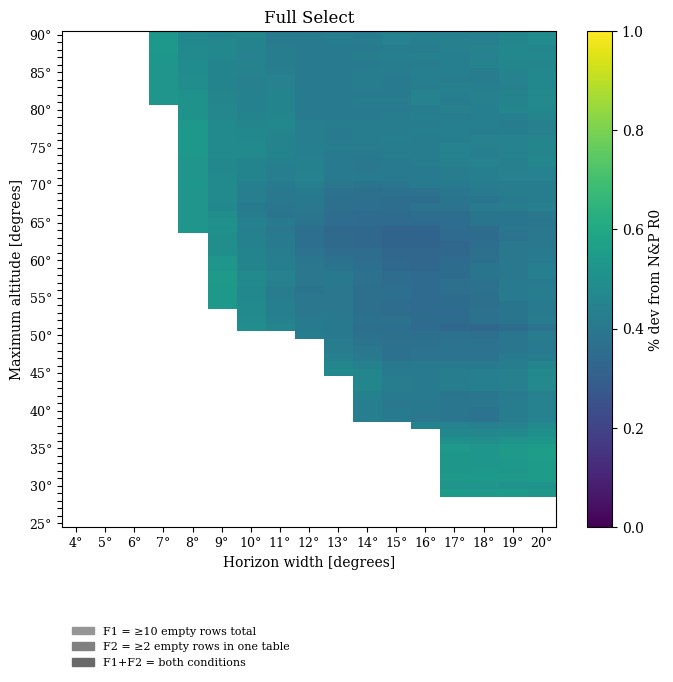

In [444]:
import numpy as np

name = select_algs[-1]
metric = metric_keys[1]
ref_val = ref_vals_dict[metric]
title = title_dict[metric] + name + " Select"
print(metric, ":", ref_val)

grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric=metric)
grid[grid <= 0] -= np.nan
grid[grid >= 0] -= ref_val # subtract reference value
grid[grid >= 0] /= ref_val # divide reference value

plot_data = np.abs(grid.copy().astype(float))
mindev = plot_data.min().min()
print("mindev", ":", mindev)
#plt.imshow(plot_data, aspect='equal')

# fig, ax = plt.subplots(figsize=(7,7))
# im = ax.imshow(plot_data, aspect = 'auto')
# fig.colorbar(im, ax=ax)
# fig.tight_layout()
# ax.invert_yaxis()
# plt.tight_layout()
# plt.show()



fig, ax  = hm.plot_heatmap(plot_data,  name + " Select", 
                           cmap = "viridis", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, 1),
                           clabel = "% dev from N&P " + metric
                           )

R1 : 1.175
mindev : 0.20178571428571435


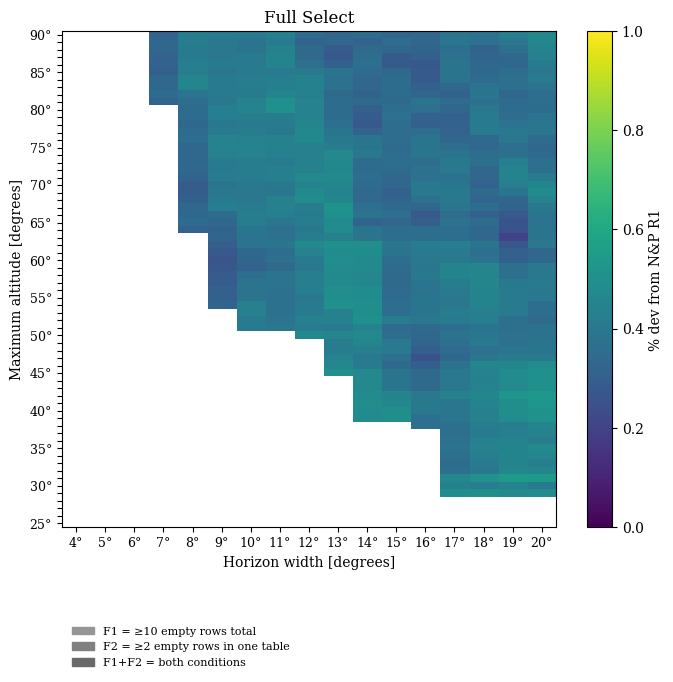

In [451]:
import numpy as np

name = select_algs[-1]
metric = metric_keys[2]
ref_val = ref_vals_dict[metric]
title = title_dict[metric] + name + " Select"
print(metric, ":", ref_val)

grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric=metric)
grid[grid <= 0] -= np.nan
grid[grid >= 0] -= ref_val # subtract reference value
grid[grid >= 0] /= ref_val # subtract reference value

plot_data = np.abs(grid.copy().astype(float))
mindev = plot_data.min().min()
print("mindev", ":", mindev)
#plt.imshow(plot_data, aspect='equal')

# fig, ax = plt.subplots(figsize=(7,7))
# im = ax.imshow(plot_data, aspect = 'auto')
# fig.colorbar(im, ax=ax)
# fig.tight_layout()
# ax.invert_yaxis()
# plt.show()

fig, ax  = hm.plot_heatmap(plot_data,  name + " Select", 
                           cmap = "viridis", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, 1),
                           clabel = "% dev from N&P " + metric
                           )

S : 1.2307692307692308
mindev : 0.0018203883495144235


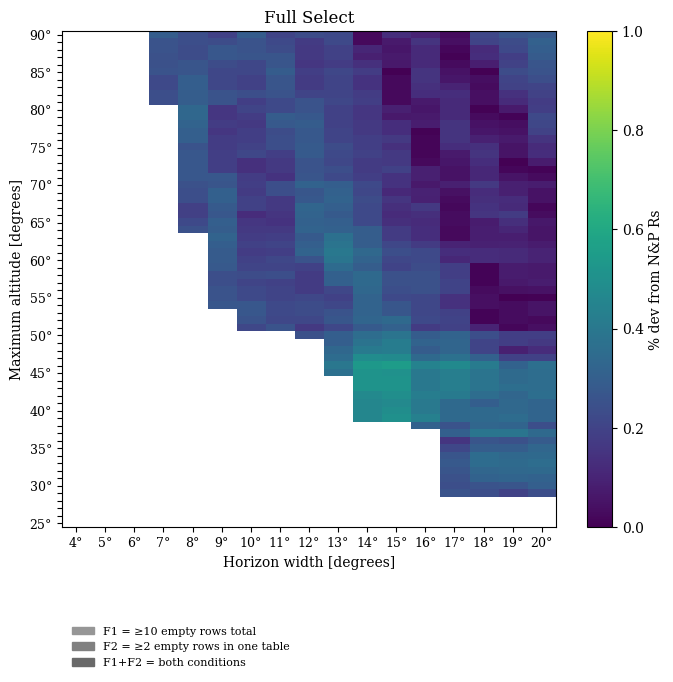

In [453]:
import numpy as np

name = select_algs[-1]
metric = metric_keys[3]
ref_val = ref_vals_dict[metric]
print(metric, ":", ref_val)

grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric=metric)
grid[grid <= 0] -= np.nan
grid[grid >= 0] -= ref_val # subtract reference value
grid[grid >= 0] /= ref_val # divide by reference value

plot_data = np.abs(grid.copy().astype(float))
mindev = plot_data.min().min()
print("mindev", ":", mindev)


fig, ax  = hm.plot_heatmap(plot_data,  name + " Select", 
                           cmap = "viridis", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, 1),
                           clabel = "% dev from N&P " + "Rs" #metric
                           )


unicount : 48
R0 : 0.7931034482758621
R1 : 1.175
S : 1.2307692307692308


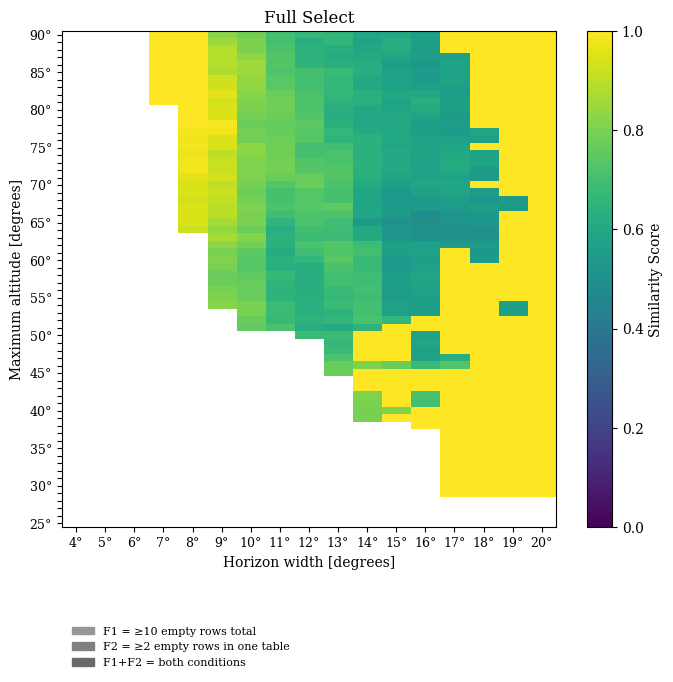

In [454]:
import numpy as np

name = select_algs[-1]

gridlist = []
for metric in metric_keys:
    ref_val = ref_vals_dict[metric]
    print(metric, ":", ref_val)
    grid = hm.make_heatmap_grid(real_sky_RSCs_dict[name], metric=metric)
    grid[grid <= 0] -= np.nan
    grid[grid >= 0] -= ref_val # subtract reference value
    grid[grid >= 0] /= ref_val # subtract reference value
    gridlist.append(grid.copy().astype(float))

sim_grid = np.sqrt((gridlist[0]**2 + gridlist[1]**2 + gridlist[2]**2 + gridlist[3]**2))
#sim_grid = np.sqrt((gridlist[1]**2 + gridlist[2]**2 + gridlist[3]**2))


fig, ax  = hm.plot_heatmap(sim_grid,  name + " Select", 
                           cmap = "viridis", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, 1),
                           clabel = "Similarity Score"
                           )


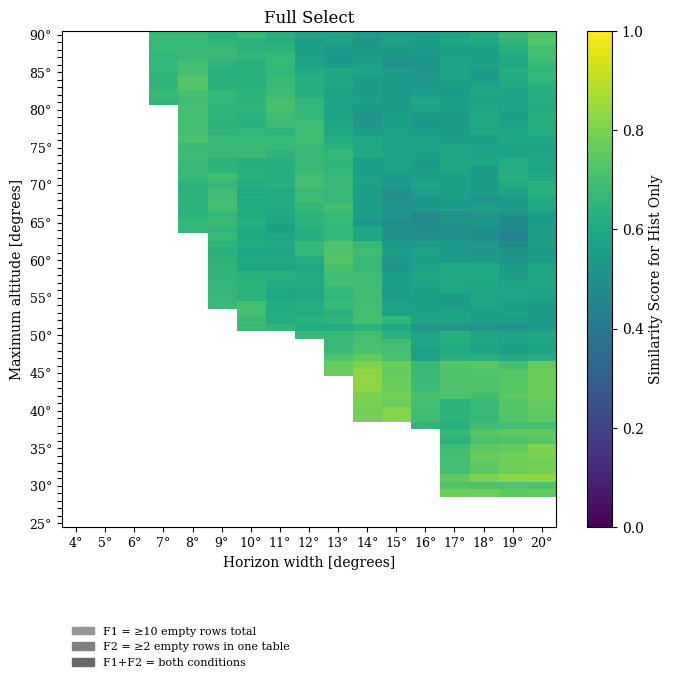

In [455]:
sim_grid = np.sqrt((gridlist[1]**2 + gridlist[2]**2 + gridlist[3]**2))


fig, ax  = hm.plot_heatmap(sim_grid,  name + " Select", 
                           cmap = "viridis", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, 1),
                           clabel = "Similarity Score for Hist Only"
                           )


0.4397558614804263


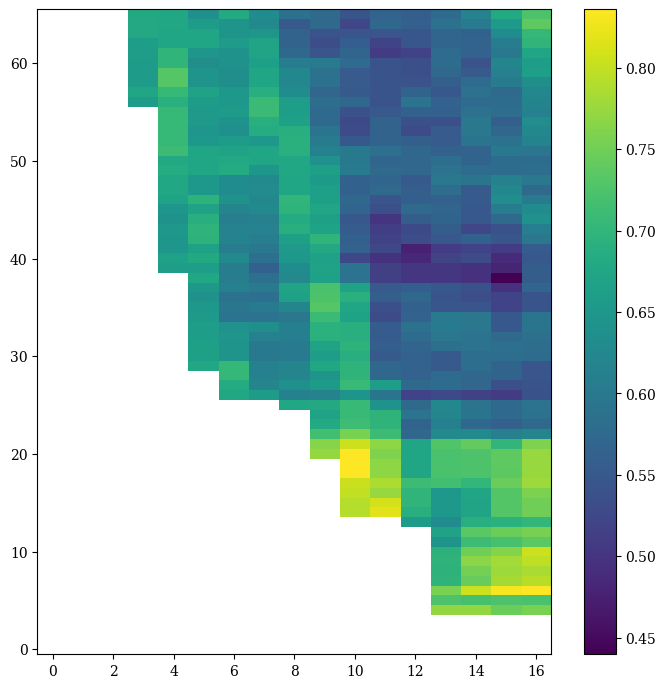

In [122]:
mindev = sim_grid.min().min()
print(mindev)

fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(sim_grid, aspect = 'auto')
fig.colorbar(im, ax=ax)
fig.tight_layout()
ax.invert_yaxis()
plt.show()

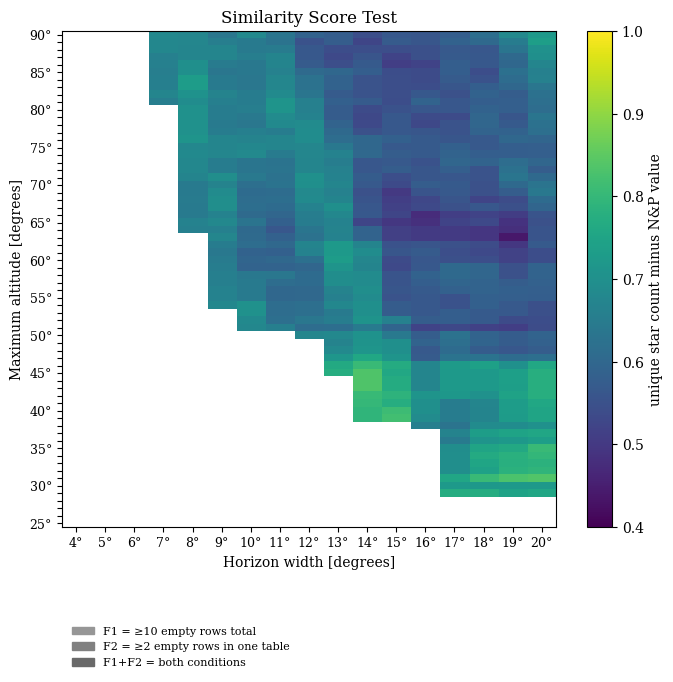

In [127]:

fig, ax  = hm.plot_heatmap(sim_grid, "Similarity Score Test", 
                           cmap = "viridis", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0.4, 1),
                           clabel = "unique star count minus N&P value"
                           )

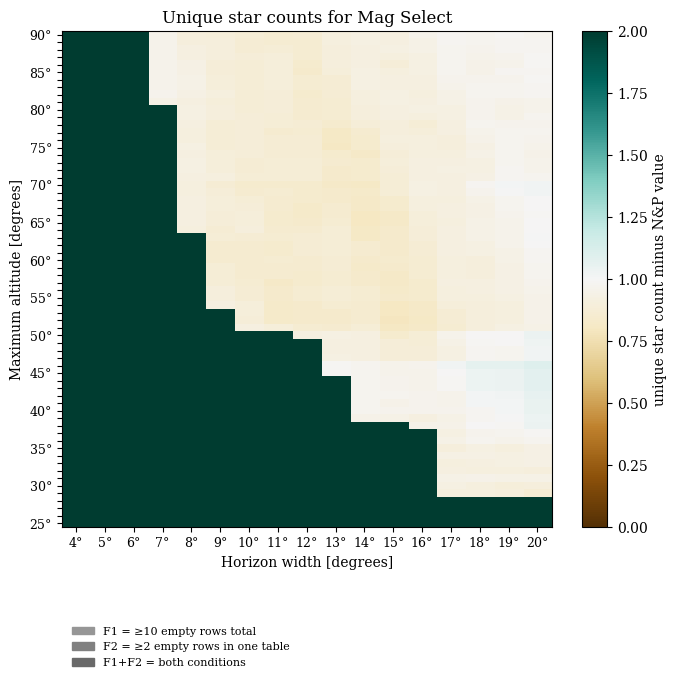

In [32]:
grid_mag_sim = (gridlist[0][1]**2 + gridlist[0][2]**2 + gridlist[0][3]**2)**(1/2)

fig, ax  = hm.plot_heatmap(grid_mag_sim, "Unique star counts for Mag Select", 
                           cmap = "BrBG", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, 2),
                           clabel = "unique star count minus N&P value"
                           )

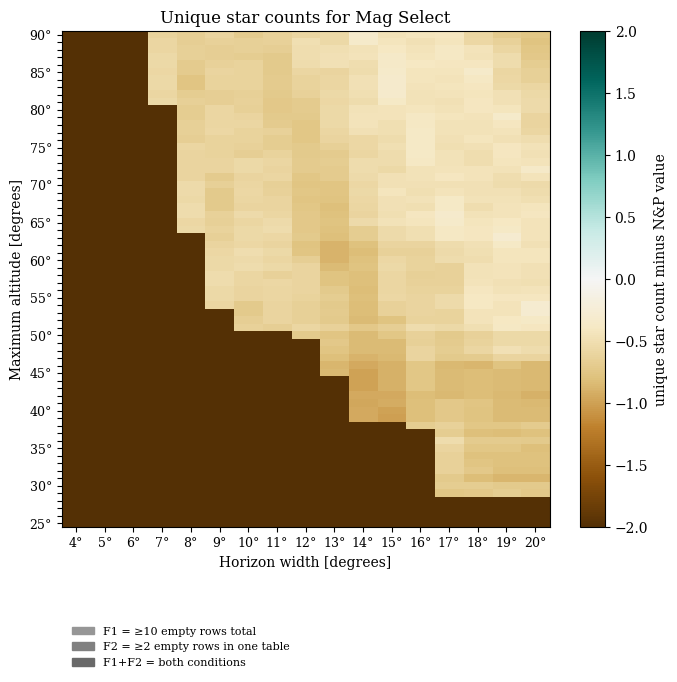

In [30]:
grid_mag_sim = sum(gridlist[-1][2:])

fig, ax  = hm.plot_heatmap(grid_mag_sim, "Unique star counts for Mag Select", 
                           cmap = "BrBG", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (-2, 0, 2),
                           clabel = "unique star count minus N&P value"
                           )

### misc

In [ ]:
# save them all 
select_algs = ['Mag', 'Name', 'DBC', 'CBin', 'Full']
savepath = "./aea26/univals/"

for name in select_algs: 
    grid = hm.make_heatmap_grid(random_sky_dict[name], metric="unicount")
    grid[grid >= 0] -= uscNP # expected value
    # dark figure
    fig, ax  = hm.plot_heatmap(grid, "Unique star counts for " + name  + " Select", 
                            cmap = "twilight", 
                            clims = (-20, 0, 20),
                            clabel = "unique star count minus N&P value"
                            )
    fig.savefig(savepath + "univals_" + name + "_dark.png")
    plt.close(fig)
    # light figure
    fig, ax  = hm.plot_heatmap(grid, "Unique star counts for " + name  + " Select", 
                           cmap = "BrBG", 
                           clims = (-20, 0, 20),
                           clabel = "unique star count minus N&P value"
                           )
    fig.savefig(savepath + "univals_" + name + "_light.png")
    plt.close(fig)

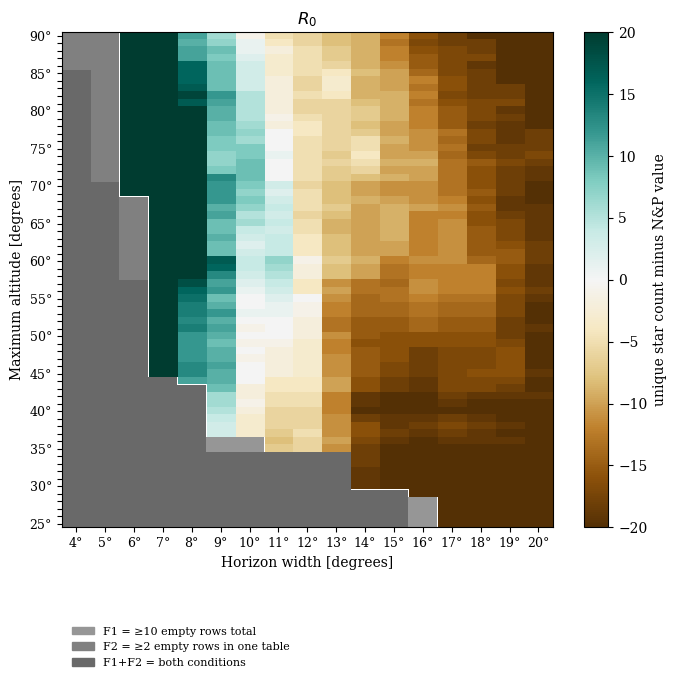

In [49]:
# Mag Select
grid = hm.make_heatmap_grid(random_sky_dict["Mag"], metric="unicount")
grid[grid >= 0] -= uscNP # expected value

fig, ax  = hm.plot_heatmap(grid, "$R_0$", 
                           cmap = "BrBG", 
                        #    annotate=False, 
                        #    figsize=(7,7), 
                        #    fail1_color = "#969696",
                        #    fail2_color = "#808080",
                        #    failb_color = "#696969",
                           clims = (-20, 0, 20),
                           clabel = "unique star count minus N&P value"
                           )
#fig.savefig(savepath +"univals_mag_light.png")
plt.show(fig)

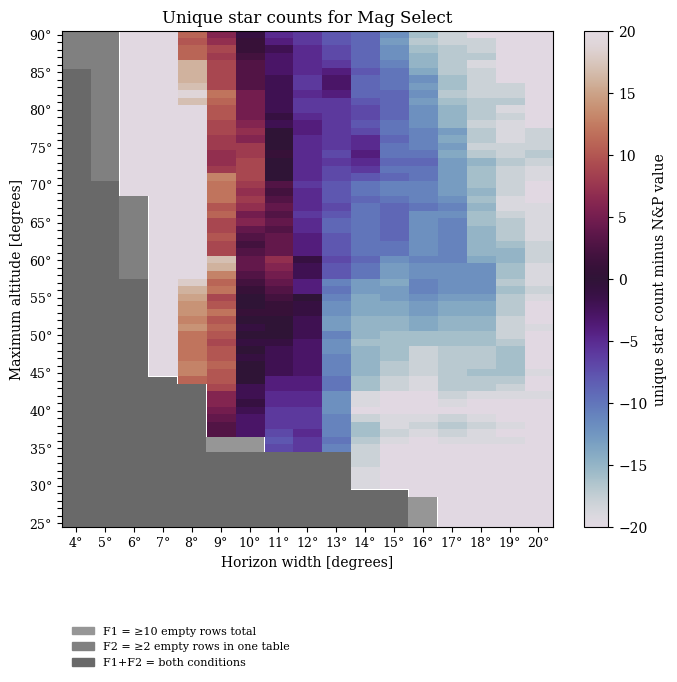

In [12]:
# Mag Select
grid = hm.make_heatmap_grid(random_sky_dict["Mag"], metric="unicount")
grid[grid >= 0] -= uscNP # expected value

fig, ax  = hm.plot_heatmap(grid, "Unique star counts for Mag Select", 
                           cmap = "twilight", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (-20, 0, 20),
                           clabel = "unique star count minus N&P value"
                           )
#fig.savefig(savepath +"univals_mag_dark.png")

In [ ]:
# Mag Select
grid_mag = hm.make_heatmap_grid(df["Mag"], metric="unicount")
grid_mag[grid_mag >= 0] -= 0 # expected value
fig, ax  = hm.plot_heatmap(grid_mag, "Unique star counts for Mag Select", 
                           cmap = "twilight", 
                           annotate=False,
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           figsize=(7,7), 
                           clims = (27, 47, 67))
fig.savefig(savepath +"univals_mag_dark.png")